# Step 4 — Risk Scoring ("At Risk" Product Watchlist)

**Project:** Customer Review Intelligence — NLP-Powered Product & Reputation Analytics

Flags products at risk of returns/bad ratings **before** it shows up in aggregate
sales numbers, by looking at whether recent reviews are trending worse than the
prior period — not just the overall average rating (which can look fine while
hiding a recent decline).

**Risk Score (0-100) combines three signals:**
1. **Trend** (55%) — is the negative review share rising vs. the prior 90 days?
2. **Severity** (45%) — are complaints concentrated in serious themes (e.g.
   "Defective on Arrival") rather than mild ones (e.g. "Lukewarm")?
3. **Volume confidence** — down-weights products with too few recent reviews
   to trust the signal (better to say "not enough data" than false-flag a
   low-volume product on noise)

**Tiers:** Critical (≥60) · High (≥35) · Watch (≥15) · Healthy (<15) · Insufficient Data

**Reads:** `data\processed\reviews_with_topics.csv`
**Writes:** `data\processed\product_risk_scores.csv`


## Setup

In [1]:
# If not already installed:
# !pip install pandas numpy matplotlib

In [2]:
"""
risk_scoring.py
-----------------
Step 4: Risk Scoring — flags products at risk of returns/bad ratings
before it shows up in aggregate sales numbers.

The idea: a product's OVERALL average rating can look fine while its
MOST RECENT reviews are trending badly — that's the early-warning signal
a simple "average rating" dashboard misses. This script scores products
on three dimensions and combines them into one Risk Score (0-100):

1. TREND — is the negative review share rising in the recent window
   vs. the prior window? (the core "early warning" signal)
2. SEVERITY — are the complaints concentrated in serious themes
   (e.g. "Defective on Arrival", "Product Fell Apart") rather than
   mild ones (e.g. "Lukewarm / Unremarkable Experience")?
3. VOLUME CONFIDENCE — down-weights products with too few recent
   reviews to draw a reliable conclusion from.

Reads:  data/processed/reviews_with_topics.csv
Writes: data/processed/product_risk_scores.csv
"""

from pathlib import Path

import numpy as np
import pandas as pd

BASE_DIR = Path(r"C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
RECENT_WINDOW_DAYS = 90     # "recent" = last 3 months of data
PRIOR_WINDOW_DAYS = 90      # compared against the 3 months before that
MIN_RECENT_REVIEWS = 8      # below this, we don't have enough signal to trust the trend

# Severity weight per complaint theme (1.0 = mild, 3.0 = severe).
# Severe = safety/functionality/money; mild = tone/preference.
SEVERITY_WEIGHTS = {
    "Defective on Arrival": 3.0,
    "Product Fell Apart / Durability": 3.0,
    "Product Odor / Chemical Smell": 2.5,
    "Damaged in Shipping": 2.0,
    "Poor Build Quality": 2.5,
    "Overpriced / Poor Value": 1.5,
    "Unresponsive Customer Support": 1.5,
    "Difficult Return Process": 1.5,
    "Sizing Issues": 1.5,
    "Confusing Instructions": 1.0,
    "Frustrating Setup Experience": 1.0,
    "Noisy During Operation": 1.5,
    "Late / Delayed Delivery": 1.5,
    "Lukewarm / Unremarkable Experience": 0.5,
}
DEFAULT_SEVERITY = 1.5  # for any theme not in the table above


def compute_risk(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["review_date"] = pd.to_datetime(df["review_date"])
    max_date = df["review_date"].max()

    recent_cutoff = max_date - pd.Timedelta(days=RECENT_WINDOW_DAYS)
    prior_cutoff = recent_cutoff - pd.Timedelta(days=PRIOR_WINDOW_DAYS)

    recent = df[df["review_date"] > recent_cutoff]
    prior = df[(df["review_date"] <= recent_cutoff) & (df["review_date"] > prior_cutoff)]

    rows = []
    for product_id, prod_group in df.groupby("product_id"):
        product_name = prod_group["product_name"].iloc[0]
        category = prod_group["category"].iloc[0]

        recent_p = recent[recent["product_id"] == product_id]
        prior_p = prior[prior["product_id"] == product_id]

        n_recent = len(recent_p)
        n_prior = len(prior_p)

        recent_neg_rate = (recent_p["sentiment_label"] == "negative").mean() if n_recent > 0 else np.nan
        prior_neg_rate = (prior_p["sentiment_label"] == "negative").mean() if n_prior > 0 else np.nan
        overall_avg_rating = prod_group["rating"].mean()
        recent_avg_rating = recent_p["rating"].mean() if n_recent > 0 else np.nan

        # --- 1. TREND SCORE (0-100): how much worse is recent vs prior? ---
        if n_recent >= MIN_RECENT_REVIEWS and not np.isnan(prior_neg_rate):
            trend_delta = recent_neg_rate - prior_neg_rate  # positive = getting worse
            trend_score = np.clip(trend_delta * 200, 0, 100)  # +50pp swing -> max score
        elif n_recent >= MIN_RECENT_REVIEWS:
            # no prior-period data to compare (new product) — use absolute recent negativity instead
            trend_score = np.clip(recent_neg_rate * 100, 0, 100)
        else:
            trend_score = 0  # not enough recent data to claim a trend

        # --- 2. SEVERITY SCORE (0-100): weighted mix of complaint themes ---
        recent_complaints = recent_p[recent_p["sentiment_label"] == "negative"]
        if len(recent_complaints) > 0:
            weights = recent_complaints["theme"].map(lambda t: SEVERITY_WEIGHTS.get(t, DEFAULT_SEVERITY))
            severity_score = np.clip(weights.mean() / 3.0 * 100, 0, 100)
            top_complaint_theme = recent_complaints["theme"].value_counts().idxmax()
        else:
            severity_score = 0
            top_complaint_theme = None

        # --- 3. VOLUME CONFIDENCE (0-1): how much do we trust this signal? ---
        volume_confidence = np.clip(n_recent / (MIN_RECENT_REVIEWS * 2), 0, 1)

        # --- COMPOSITE RISK SCORE ---
        raw_score = 0.55 * trend_score + 0.45 * severity_score
        risk_score = raw_score * volume_confidence

        if n_recent < MIN_RECENT_REVIEWS:
            risk_tier = "Insufficient Data"
        elif risk_score >= 60:
            risk_tier = "Critical"
        elif risk_score >= 35:
            risk_tier = "High"
        elif risk_score >= 15:
            risk_tier = "Watch"
        else:
            risk_tier = "Healthy"

        rows.append({
            "product_id": product_id,
            "product_name": product_name,
            "category": category,
            "overall_avg_rating": round(overall_avg_rating, 2),
            "recent_avg_rating": round(recent_avg_rating, 2) if n_recent > 0 else None,
            "n_reviews_total": len(prod_group),
            "n_reviews_recent": n_recent,
            "n_reviews_prior": n_prior,
            "recent_negative_rate": round(recent_neg_rate, 3) if n_recent > 0 else None,
            "prior_negative_rate": round(prior_neg_rate, 3) if n_prior > 0 else None,
            "trend_score": round(trend_score, 1),
            "severity_score": round(severity_score, 1),
            "volume_confidence": round(volume_confidence, 2),
            "risk_score": round(risk_score, 1),
            "risk_tier": risk_tier,
            "top_complaint_theme": top_complaint_theme,
        })

    result = pd.DataFrame(rows).sort_values("risk_score", ascending=False).reset_index(drop=True)
    return result


if __name__ == "__main__":
    df = pd.read_csv(PROCESSED_DIR / "reviews_with_topics.csv")
    print(f"Loaded {len(df)} reviews.")

    risk_df = compute_risk(df)

    out_path = PROCESSED_DIR / "product_risk_scores.csv"
    risk_df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

    print("\nRisk tier counts:")
    print(risk_df["risk_tier"].value_counts())

    print("\n--- WATCHLIST: Critical & High risk products ---")
    watchlist = risk_df[risk_df["risk_tier"].isin(["Critical", "High"])]
    print(watchlist[["product_name", "category", "risk_score", "risk_tier",
                      "recent_negative_rate", "prior_negative_rate",
                      "top_complaint_theme"]].to_string(index=False))


Loaded 6500 reviews.
Saved: C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system\data\processed\product_risk_scores.csv

Risk tier counts:
risk_tier
Healthy              12
Watch                11
Insufficient Data     9
High                  3
Name: count, dtype: int64

--- WATCHLIST: Critical & High risk products ---
             product_name    category  risk_score risk_tier  recent_negative_rate  prior_negative_rate                top_complaint_theme
     Electric Kettle 1.7L     Kitchen        47.8      High                 0.516                0.226 Lukewarm / Unremarkable Experience
     Toddler Balance Bike Baby & Kids        45.1      High                 0.750                0.525             Confusing Instructions
4K Streaming Media Player Electronics        36.9      High                 0.222                0.045      Unresponsive Customer Support


## The Watchlist

In [3]:
watchlist_cols = ['product_name','category','risk_score','risk_tier',
                   'recent_negative_rate','prior_negative_rate',
                   'overall_avg_rating','recent_avg_rating','top_complaint_theme']
risk_df[risk_df['risk_tier'].isin(['Critical','High','Watch'])][watchlist_cols]

,product_name,category,risk_score,risk_tier,recent_negative_rate,prior_negative_rate,overall_avg_rating,recent_avg_rating,top_complaint_theme
0,Electric Kettle 1.7L,Kitchen,47.8,High,0.516,0.226,3.34,3.00,Lukewarm / Unremarkable Experience
1,Toddler Balance Bike,Baby & Kids,45.1,High,0.750,0.525,3.13,2.21,Confusing Instructions
2,4K Streaming Media Player,Electronics,36.9,High,0.222,0.045,4.22,3.70,Unresponsive Customer Support
3,Memory Foam Seat Cushion,Home & Office,33.0,Watch,0.273,0.168,3.91,3.64,Overpriced / Poor Value
4,Cat Water Fountain,Pet Supplies,32.0,Watch,0.833,0.588,2.31,1.83,Frustrating Setup Experience
5,Bluetooth Speaker Mini,Electronics,27.6,Watch,0.596,0.512,3.16,2.58,Frustrating Setup Experience
6,Smart Fitness Tracker,Electronics,25.9,Watch,0.267,0.083,4.27,4.13,Lukewarm / Unremarkable Experience
7,Retractable Dog Leash,Pet Supplies,25.5,Watch,0.697,0.673,2.26,2.18,Unresponsive Customer Support
8,Stainless Steel Air Fryer,Kitchen,25.5,Watch,0.444,0.377,3.15,3.07,Sizing Issues
9,Vacuum Sealer Food Storage,Kitchen,23.4,Watch,0.100,0.133,4.25,4.00,Product Odor / Chemical Smell


## Risk score by product (all products, sorted)

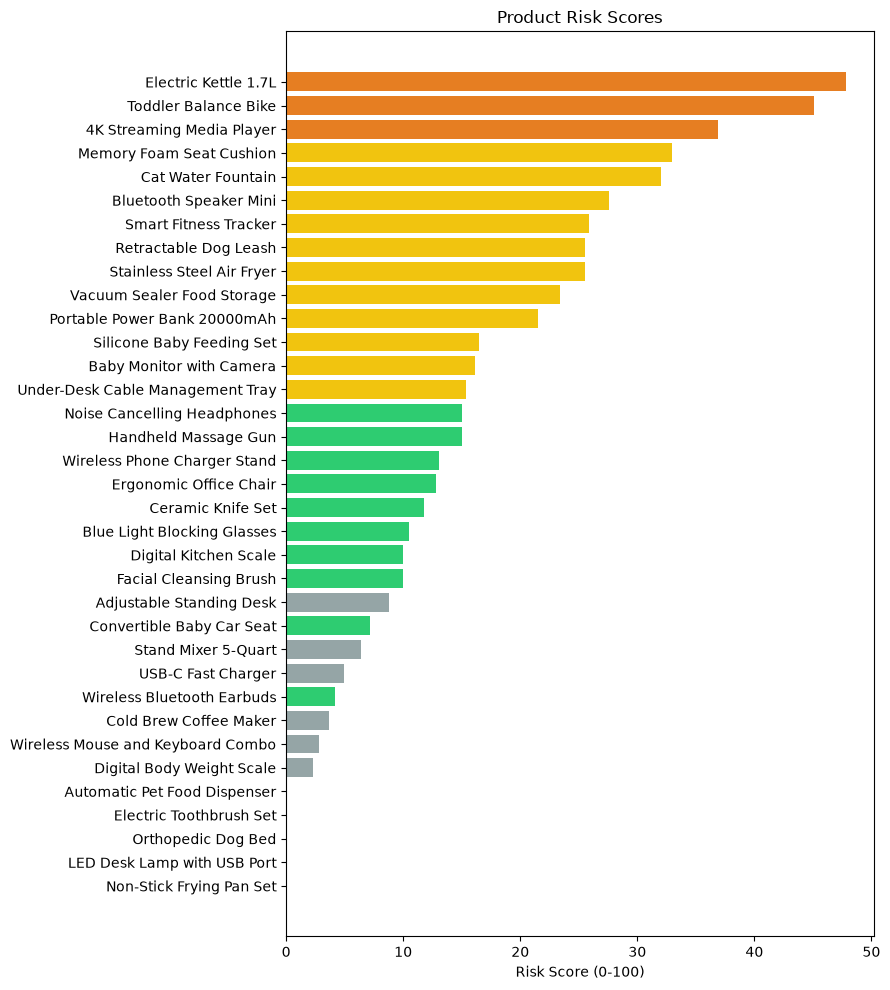

In [4]:
import matplotlib.pyplot as plt

tier_colors = {'Critical':'#c0392b','High':'#e67e22','Watch':'#f1c40f',
                'Healthy':'#2ecc71','Insufficient Data':'#95a5a6'}
plot_df = risk_df.sort_values('risk_score', ascending=True)
colors = plot_df['risk_tier'].map(tier_colors)

plt.figure(figsize=(9,10))
plt.barh(plot_df['product_name'], plot_df['risk_score'], color=colors)
plt.xlabel('Risk Score (0-100)')
plt.title('Product Risk Scores')
plt.tight_layout()
plt.show()

## Why the overall average rating can hide a real problem
This is the core "early warning" idea: a product's all-time average rating can
still look decent even while its *most recent* reviews are trending badly.
The chart below compares overall average rating vs. recent average rating —
watch for products where the recent bar drops well below the overall bar.

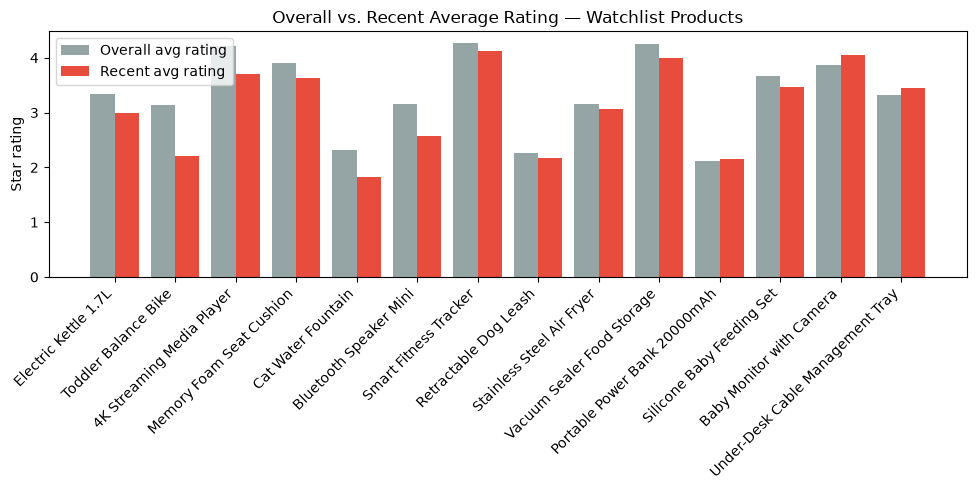

In [5]:
watch_df = risk_df[risk_df['risk_tier'].isin(['Critical','High','Watch'])].sort_values('risk_score', ascending=False)

x = range(len(watch_df))
plt.figure(figsize=(10,5))
plt.bar([i-0.2 for i in x], watch_df['overall_avg_rating'], width=0.4, label='Overall avg rating', color='#95a5a6')
plt.bar([i+0.2 for i in x], watch_df['recent_avg_rating'], width=0.4, label='Recent avg rating', color='#e74c3c')
plt.xticks(x, watch_df['product_name'], rotation=45, ha='right')
plt.ylabel('Star rating')
plt.title('Overall vs. Recent Average Rating — Watchlist Products')
plt.legend()
plt.tight_layout()
plt.show()

## Monthly sentiment trend for the top 3 at-risk products
See the decline unfold month by month.

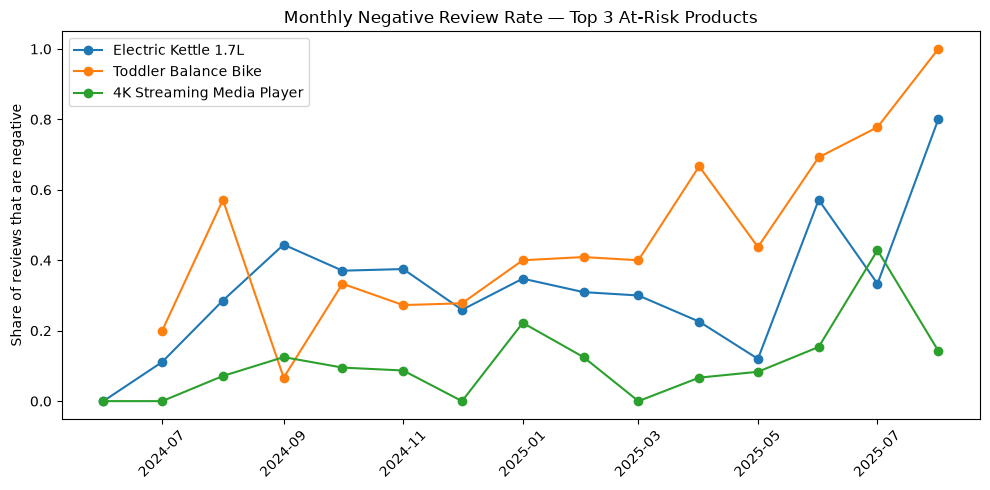

In [6]:
top3_ids = risk_df.head(3)['product_id'].tolist()
df['review_date'] = pd.to_datetime(df['review_date'])
df['review_month'] = df['review_date'].dt.to_period('M').dt.to_timestamp()

plt.figure(figsize=(10,5))
for pid in top3_ids:
    p_df = df[df['product_id'] == pid]
    monthly_neg = p_df.groupby('review_month').apply(lambda x: (x['sentiment_label']=='negative').mean())
    name = p_df['product_name'].iloc[0]
    plt.plot(monthly_neg.index, monthly_neg.values, marker='o', label=name)

plt.title('Monthly Negative Review Rate — Top 3 At-Risk Products')
plt.ylabel('Share of reviews that are negative')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## A note on false positives
Not every flagged product will turn out to be a real emerging quality problem —
some are just normal sample-to-sample noise in a 90-day window. That's a real,
expected property of any early-warning system: it trades some false positives
for catching real problems earlier than an aggregate rating would. In a
production setting you'd validate flagged products against actual return-rate
data before acting, and possibly widen the window or require the trend to
persist for two consecutive periods before escalating to 'Critical'.